![TecNM](assets/encabezado.png)

---

# Machine Learning y Deep Learning
## Unidad 2 · Modelos de Predicción Supervisados

Práctica 5 — Máquinas de Soporte para Regresión (SVR)

> **Facilitador:** Dr. José Gabriel Rodríguez Rivas  
> **Alumno:** Christian Gibran Espituñal Villanueva

---

## Objetivo

Construir, evaluar y optimizar un modelo de **Máquinas de Soporte para Regresión (SVR)** para predecir el precio de automóviles, analizando el efecto del kernel, el escalamiento y los hiperparámetros sobre el rendimiento del modelo.

---

## Marco Teórico

SVR busca encontrar una función $f(\mathbf{x})$ que se desvíe como máximo $\varepsilon$ del valor real $y$ para cada punto de entrenamiento, minimizando al mismo tiempo la complejidad del modelo (norma del vector de pesos $\mathbf{w}$):

$$\min_{\mathbf{w}, b, \xi} \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^{n}(\xi_i + \xi_i^*)$$

sujeto a $|y_i - f(\mathbf{x}_i)| \leq \varepsilon + \xi_i$, donde $\xi_i, \xi_i^* \geq 0$ son variables de holgura.

Solo los puntos fuera del margen $\varepsilon$ (los **vectores de soporte**) influyen en el modelo. El kernel RBF proyecta los datos a un espacio de mayor dimensión mediante:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \exp\left(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2\right)$$

| Técnica | Linealidad | Flexibilidad | Requiere Escalado | Sobreajuste | Interpretabilidad |
|---|---|---|---|---|---|
| Regresión Lineal | Alta | Baja | No | Bajo | Alta |
| Árbol / Random Forest | Baja | Alta | No | Medio-Bajo | Media |
| **SVR** | **Muy Baja** | **Alta** | **Sí** | **Bajo** | **Baja** |

---

## Nota sobre GPU

scikit-learn ejecuta SVR en **CPU**. PyTorch se utiliza en este notebook exclusivamente para detectar y reportar las propiedades del dispositivo CUDA disponible.

---

## Conjunto de Datos

Archivo `datasets/autos2.csv` — especificaciones técnicas y precios de mercado de automóviles.

| Variable | Tipo | Descripción |
|---|---|---|
| `horsepower` | Predictora | Potencia del motor (cv) |
| `engine-size` | Predictora | Cilindrada del motor (cm³) |
| `city-mpg` | Predictora | Consumo urbano (millas/galón) |
| `wheel-base` | Predictora | Distancia entre ejes (pulgadas) |
| `bore` | Predictora | Diámetro del cilindro (pulgadas) |
| `price` | Objetivo | Precio del vehículo (USD) |

---

## Contenido

1. [Entorno y librerías](#1.-Entorno-y-librerías)
2. [Detección de dispositivo (PyTorch)](#2.-Detección-de-dispositivo)
3. [Carga y exploración inicial](#3.-Carga-y-exploración-inicial)
4. [Preprocesamiento y escalamiento](#4.-Preprocesamiento-y-escalamiento)
5. [División de datos](#5.-División-de-datos)
6. [Modelo base SVR](#6.-Modelo-base-SVR)
7. [Análisis de kernels](#7.-Análisis-de-kernels)
8. [Optimización con GridSearchCV](#8.-Optimización-con-GridSearchCV)
9. [Modelo optimizado](#9.-Modelo-optimizado)
10. [Diagnóstico de residuos](#10.-Diagnóstico-de-residuos)
11. [Comparación de modelos](#11.-Comparación-de-modelos)
12. [Conclusiones](#12.-Conclusiones)

In [3]:
import subprocess
import sys

libraries = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scipy",
    "ipython",
    "torch",
    "scikit-learn",
    "statsmodels"
]

for lib in libraries:
    print(f"Instalando {lib}...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", lib])

print("✅ Instalación completada.")

Instalando numpy...
Instalando pandas...
Instalando matplotlib...
Instalando seaborn...
Instalando scipy...
Instalando ipython...
Instalando torch...
Instalando scikit-learn...
Instalando statsmodels...
✅ Instalación completada.


---
## 1. Entorno y librerías

In [4]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy.stats as stats
from IPython.display import display

# PyTorch — solo para detección e información del dispositivo CUDA
import torch

from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.nonparametric.smoothers_lowess import lowess

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.28,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans',
})

C_BLUE, C_ORANGE, C_GREEN, C_RED, C_PURPLE = (
    '#005F9E', '#E87722', '#3DAD6B', '#C0392B', '#8E44AD'
)
PALETTE = [C_BLUE, C_ORANGE, C_GREEN, C_RED, C_PURPLE]
sns.set_theme(style='whitegrid', palette=PALETTE)

RANDOM_STATE = 42
FEATURES     = ['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']
TARGET       = 'price'
DATASET_PATH = 'datasets/autos2.csv'

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Detección de dispositivo (PyTorch)

PyTorch se usa exclusivamente para detectar y reportar el hardware CUDA disponible. El entrenamiento de SVR ocurre en CPU vía scikit-learn.

In [5]:
CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE         = torch.device('cuda' if CUDA_AVAILABLE else 'cpu')

rows = [
    ('PyTorch',          torch.__version__),
    ('CUDA disponible',  str(CUDA_AVAILABLE)),
    ('Dispositivo CUDA', str(DEVICE)),
]

if CUDA_AVAILABLE:
    props = torch.cuda.get_device_properties(0)
    rows += [
        ('GPU',          torch.cuda.get_device_name(0)),
        ('Compute cap.', f'sm_{props.major}{props.minor}  ({props.multi_processor_count} SMs)'),
        ('VRAM total',   f'{props.total_memory / 1024**3:.2f} GB'),
        ('CUDA version', torch.version.cuda),
    ]

rows += [
    ('SVR backend',   'sklearn.svm.SVR'),
    ('SVR ejecucion', 'CPU'),
]

display(
    pd.DataFrame(rows, columns=['Parametro', 'Valor'])
    .style.hide(axis='index')
    .set_caption('Configuracion del entorno de computo')
)

Parametro,Valor
PyTorch,2.10.0+cpu
CUDA disponible,False
Dispositivo CUDA,cpu
SVR backend,sklearn.svm.SVR
SVR ejecucion,CPU


---
## 3. Carga y exploración inicial

In [6]:
df = pd.read_csv(DATASET_PATH)

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
display(df.head())

Dimensiones del dataset: 201 filas x 32 columnas


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type_code,diesel,gas,fuel-type-map,horsepower-binned
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,13495.0,11.190476,1,False,True,1,Low
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,16500.0,11.190476,1,False,True,1,Low
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,5000.0,19,9.038462,16500.0,12.368421,1,False,True,1,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,5500.0,24,7.833333,13950.0,9.791667,1,False,True,1,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,5500.0,18,10.681818,17450.0,13.055556,1,False,True,1,Low


In [7]:
display(
    df[FEATURES + [TARGET]]
    .describe().T
    .style.format(precision=2)
    .background_gradient(cmap='Blues', subset=['mean', 'std'])
    .set_caption('Estadisticas descriptivas')
)

,count,mean,std,min,25%,50%,75%,max
horsepower,201.00,103.40,37.37,48.00,70.00,95.00,116.00,262.00
engine-size,201.00,126.88,41.55,61.00,98.00,120.00,141.00,326.00
city-mpg,201.00,25.18,6.42,13.00,19.00,24.00,30.00,49.00
wheel-base,201.00,98.80,6.07,86.60,94.50,97.00,102.40,120.90
bore,201.00,3.33,0.27,2.54,3.15,3.31,3.58,3.94
price,201.00,13207.13,7947.07,5118.00,7775.00,10295.00,16500.00,45400.00


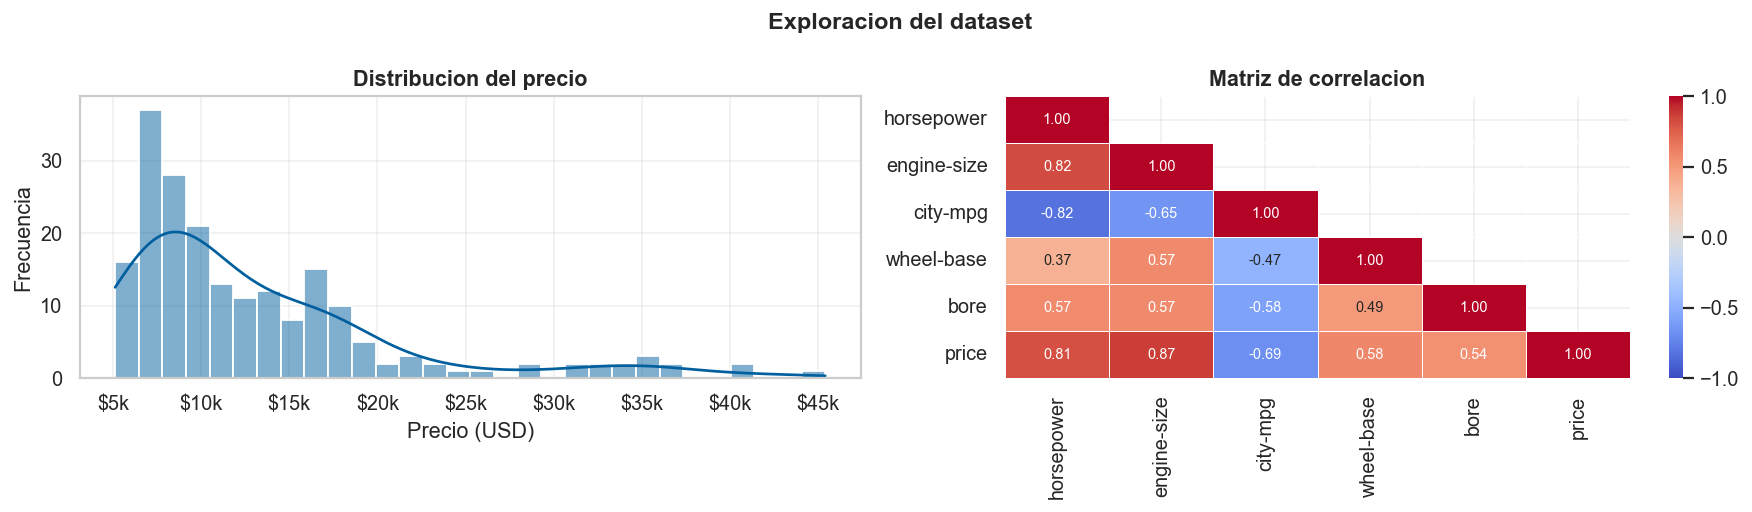

In [8]:
fmt_usd = mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k')

corr = df[FEATURES + [TARGET]].corr()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Exploracion del dataset', fontsize=13, fontweight='bold')

sns.histplot(df[TARGET].dropna(), bins=30, kde=True,
             color=C_BLUE, edgecolor='white', ax=axes[0])
axes[0].xaxis.set_major_formatter(fmt_usd)
axes[0].set_title('Distribucion del precio')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=axes[1],
            annot_kws={'size': 8})
axes[1].set_title('Matriz de correlacion')

plt.tight_layout()
plt.show()

---
## 4. Preprocesamiento y escalamiento

SVR es sensible a la escala de los datos. Se aplica `StandardScaler` tanto a las variables predictoras como a la variable objetivo para que el optimizador del kernel opere en un espacio normalizado. La inversa del escalador de `y` se usa al evaluar para recuperar la escala original en USD.

In [9]:
data = df[FEATURES + [TARGET]].dropna().reset_index(drop=True)

print(f'Registros originales    : {len(df)}')
print(f'Registros tras limpiar  : {len(data)}')
print(f'Valores nulos restantes : {data.isnull().sum().sum()}')

Registros originales    : 201
Registros tras limpiar  : 201
Valores nulos restantes : 0


---
## 5. División de datos

In [10]:
X = data[FEATURES]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# Escalado — se ajusta solo con datos de entrenamiento para evitar data leakage
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)
y_train_sc = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

print(f'Total         : {len(data)}')
print(f'Entrenamiento : {len(X_train)} ({len(X_train)/len(data):.0%})')
print(f'Prueba        : {len(X_test)}  ({len(X_test)/len(data):.0%})')
print()
print('Escaladores ajustados con datos de entrenamiento unicamente.')
print(f'Media de precio en train : ${scaler_y.mean_[0]:,.2f} USD')
print(f'Desv. estandar           : ${scaler_y.scale_[0]:,.2f} USD')

Total         : 201
Entrenamiento : 160 (80%)
Prueba        : 41  (20%)

Escaladores ajustados con datos de entrenamiento unicamente.
Media de precio en train : $12,573.68 USD
Desv. estandar           : $6,754.73 USD


---
## 6. Modelo base SVR

Punto de partida con `kernel='rbf'`, `C=100`, `epsilon=0.2` — los parámetros del notebook original.

  SVR base  (rbf, C=100, eps=0.2)
  ──────────────────────────────────────────────
  RMSE           : $  4,364.66 USD
  MAE            : $  2,944.05 USD
  R2             :       0.8443
  CV-R2 (5-fold) :       0.7428  (espacio escalado)
  Tiempo ajuste  :      9.03 ms  [CPU]



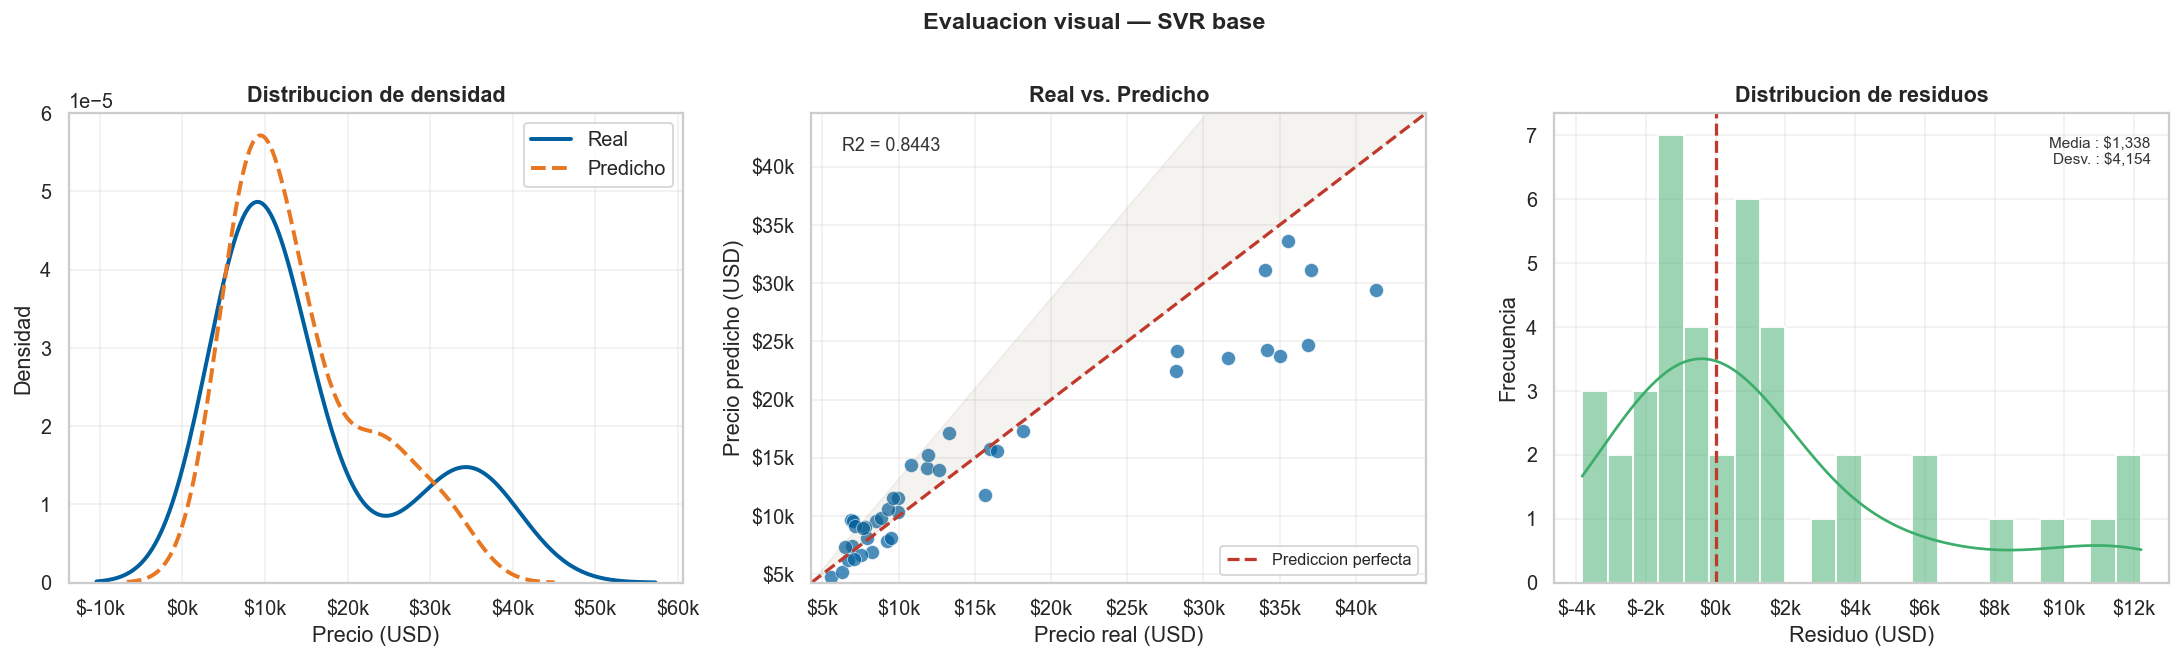

In [11]:
def predecir_svr(modelo, X_sc, scaler_y):
    """Predice con SVR y devuelve valores en la escala original (USD)."""
    y_sc = modelo.predict(X_sc)
    return scaler_y.inverse_transform(y_sc.reshape(-1, 1)).ravel()


def evaluar(modelo, X_tr_sc, y_tr_sc, X_te_sc, y_te, scaler_y,
            nombre='Modelo', cv=5):
    """Ajusta el modelo, calcula metricas e imprime resumen."""
    t0    = time.perf_counter()
    modelo.fit(X_tr_sc, y_tr_sc)
    t_fit = (time.perf_counter() - t0) * 1e3

    y_pred = predecir_svr(modelo, X_te_sc, scaler_y)
    mse    = mean_squared_error(y_te, y_pred)
    rmse   = np.sqrt(mse)
    mae    = mean_absolute_error(y_te, y_pred)
    r2     = r2_score(y_te, y_pred)

    # CV-R2 usando pipeline mental: el modelo ya esta escalado, se evalua en espacio escalado
    cv_r2 = cross_val_score(
        modelo, X_tr_sc, y_tr_sc, cv=cv, scoring='r2'
    ).mean()

    print(f'  {nombre}')
    print(f'  {"─"*46}')
    print(f'  RMSE           : ${rmse:>10,.2f} USD')
    print(f'  MAE            : ${mae:>10,.2f} USD')
    print(f'  R2             : {r2:>12.4f}')
    print(f'  CV-R2 ({cv}-fold) : {cv_r2:>12.4f}  (espacio escalado)')
    print(f'  Tiempo ajuste  : {t_fit:>9.2f} ms  [CPU]')
    print()
    return {'nombre': nombre, 'mse': mse, 'rmse': rmse,
            'mae': mae, 'r2': r2, 'cv_r2': cv_r2,
            'y_pred': y_pred, 'model': modelo, 't_fit': t_fit}


def panel_evaluacion(y_test, y_pred, titulo=''):
    """Panel de tres graficas: KDE, scatter real vs predicho, residuos."""
    fmt = mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k')
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle(f'Evaluacion visual — {titulo}',
                 fontsize=13, fontweight='bold', y=1.01)
    r2_val = r2_score(y_test, y_pred)

    sns.kdeplot(y_test,  label='Real',     color=C_BLUE,   linewidth=2.2, ax=axes[0])
    sns.kdeplot(y_pred,  label='Predicho', color=C_ORANGE,
                linewidth=2.2, linestyle='--', ax=axes[0])
    axes[0].xaxis.set_major_formatter(fmt)
    axes[0].set_title('Distribucion de densidad')
    axes[0].set_xlabel('Precio (USD)')
    axes[0].set_ylabel('Densidad')
    axes[0].legend(frameon=True)

    lim = (min(np.asarray(y_test).min(), y_pred.min()) * 0.90,
           max(np.asarray(y_test).max(), y_pred.max()) * 1.08)
    axes[1].scatter(y_test, y_pred, color=C_BLUE, alpha=0.70,
                    edgecolors='white', linewidths=0.4, s=60)
    axes[1].plot(lim, lim, '--', color=C_RED, linewidth=1.8,
                 label='Prediccion perfecta')
    axes[1].fill_between(lim, lim, [lim[0], lim[1]*1.5], alpha=0.04, color=C_GREEN)
    axes[1].fill_between(lim, [lim[0], lim[1]*1.5], lim,  alpha=0.04, color=C_RED)
    axes[1].xaxis.set_major_formatter(fmt)
    axes[1].yaxis.set_major_formatter(fmt)
    axes[1].set_xlim(*lim)
    axes[1].set_ylim(*lim)
    axes[1].set_title('Real vs. Predicho')
    axes[1].set_xlabel('Precio real (USD)')
    axes[1].set_ylabel('Precio predicho (USD)')
    axes[1].legend(fontsize=9, frameon=True)
    axes[1].text(0.05, 0.92, f'R2 = {r2_val:.4f}',
                 transform=axes[1].transAxes, fontsize=10, color='#333')

    residuos = np.asarray(y_test) - y_pred
    sns.histplot(residuos, bins=22, kde=True, color=C_GREEN,
                 edgecolor='white', ax=axes[2])
    axes[2].axvline(0, color=C_RED, linestyle='--', linewidth=1.8)
    axes[2].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
    axes[2].set_title('Distribucion de residuos')
    axes[2].set_xlabel('Residuo (USD)')
    axes[2].set_ylabel('Frecuencia')
    axes[2].text(0.97, 0.95,
                 f'Media : ${residuos.mean():,.0f}\nDesv. : ${residuos.std():,.0f}',
                 transform=axes[2].transAxes, fontsize=8.5,
                 va='top', ha='right', color='#333')

    plt.tight_layout()
    plt.show()


svr_base = SVR(kernel='rbf', C=100, epsilon=0.2)
res_base = evaluar(svr_base, X_train_sc, y_train_sc,
                   X_test_sc, y_test, scaler_y,
                   nombre='SVR base  (rbf, C=100, eps=0.2)')

panel_evaluacion(y_test, res_base['y_pred'], 'SVR base')

---
## 7. Análisis de kernels

Comparación del R² de prueba para cada tipo de kernel disponible en `sklearn.svm.SVR`, manteniendo `C=100` y `epsilon=0.2` constantes.

kernel,R2 Test,RMSE Test,Vectores de soporte
linear,0.7076,"$5,981",81
rbf,0.8443,"$4,365",80
poly,0.7566,"$5,457",99
sigmoid,-93579.3901,"$3,383,675",160


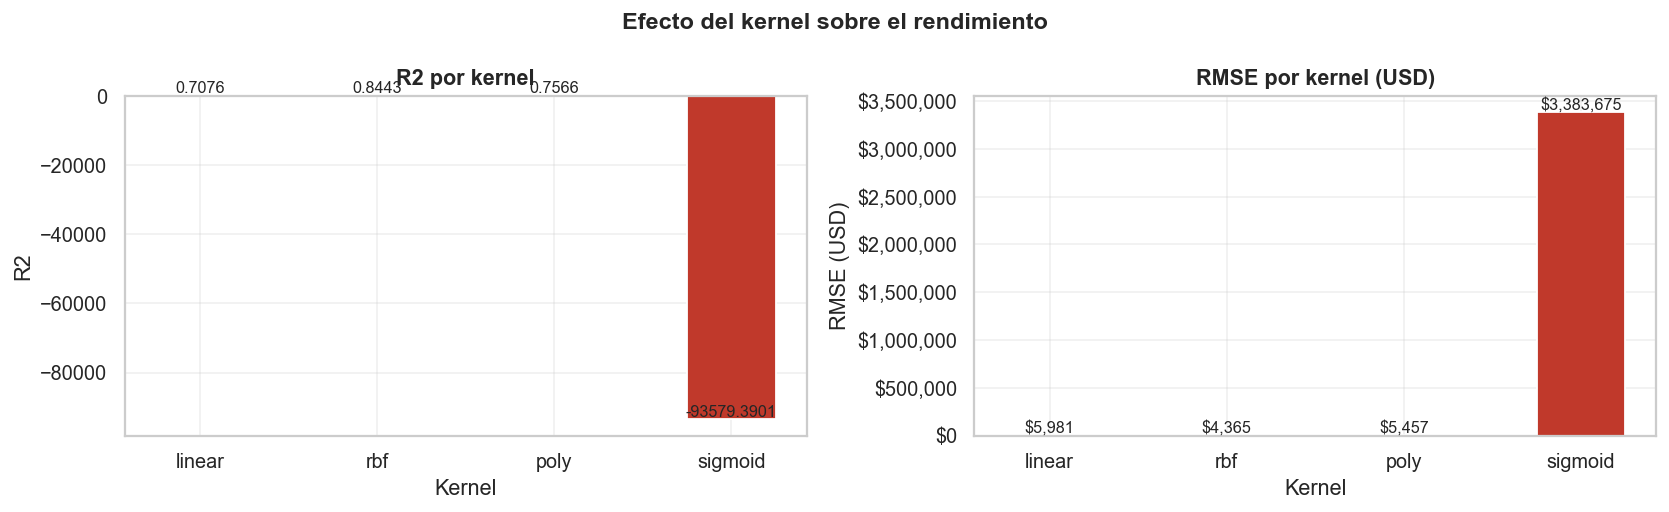

In [12]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
res_kernels = []

for k in kernels:
    m = SVR(kernel=k, C=100, epsilon=0.2)
    m.fit(X_train_sc, y_train_sc)
    yp = predecir_svr(m, X_test_sc, scaler_y)
    res_kernels.append({
        'kernel'    : k,
        'R2 Test'   : r2_score(y_test, yp),
        'RMSE Test' : np.sqrt(mean_squared_error(y_test, yp)),
        'Vectores de soporte': int(m.support_.shape[0]),
    })

df_k = pd.DataFrame(res_kernels)

display(
    df_k.style
    .format({'R2 Test': '{:.4f}', 'RMSE Test': '${:,.0f}'})
    .highlight_max(subset=['R2 Test'],   color='#D4EFDF')
    .highlight_min(subset=['RMSE Test'], color='#D4EFDF')
    .hide(axis='index')
    .set_caption('Comparacion de kernels  (C=100, epsilon=0.2)')
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Efecto del kernel sobre el rendimiento', fontsize=13, fontweight='bold')

axes[0].bar(df_k['kernel'], df_k['R2 Test'], color=PALETTE[:4], edgecolor='white', width=0.5)
for i, (v, k) in enumerate(zip(df_k['R2 Test'], df_k['kernel'])):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
axes[0].set_title('R2 por kernel')
axes[0].set_ylabel('R2')
axes[0].set_xlabel('Kernel')

axes[1].bar(df_k['kernel'], df_k['RMSE Test'], color=PALETTE[:4], edgecolor='white', width=0.5)
for i, (v, k) in enumerate(zip(df_k['RMSE Test'], df_k['kernel'])):
    axes[1].text(i, v + 80, f'${v:,.0f}', ha='center', va='bottom', fontsize=9)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_title('RMSE por kernel (USD)')
axes[1].set_ylabel('RMSE (USD)')
axes[1].set_xlabel('Kernel')

plt.tight_layout()
plt.show()

---
## 8. Optimización con GridSearchCV

`GridSearchCV` explora exhaustivamente el espacio de hiperparámetros usando validación cruzada de 3 pliegues sobre los datos escalados. El número total de ajustes es:

$$\underbrace{3}_{\text{kernels}} \times \underbrace{4}_{C} \times \underbrace{3}_{\varepsilon} \times \underbrace{5}_{\gamma} = 180 \text{ combinaciones} \times 3 \text{ folds} = 540 \text{ ajustes}$$

In [13]:
param_grid = {
    'kernel' : ['linear', 'rbf', 'poly'],
    'C'      : [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 1],
    'gamma'  : ['scale', 'auto', 0.01, 0.1, 1],
}

n_combo = 1
for v in param_grid.values():
    n_combo *= len(v)
print(f'Combinaciones a evaluar : {n_combo}')
print(f'Ajustes totales (cv=3)  : {n_combo * 3}')
print()

grid_search = GridSearchCV(
    SVR(), param_grid, cv=3, scoring='r2',
    n_jobs=-1, verbose=1,
)

t0 = time.perf_counter()
grid_search.fit(X_train_sc, y_train_sc)
t_gs = time.perf_counter() - t0

best_params = grid_search.best_params_
best_cv_r2  = grid_search.best_score_

print(f'\nTiempo de busqueda      : {t_gs:.1f} s  [CPU n_jobs=-1]')
print(f'Mejor R2 (CV-3)         : {best_cv_r2:.4f}')
print(f'Mejores parametros:')
for k, v in best_params.items():
    print(f'    {k:<10}: {v}')

Combinaciones a evaluar : 180
Ajustes totales (cv=3)  : 540

Fitting 3 folds for each of 180 candidates, totalling 540 fits

Tiempo de busqueda      : 56.3 s  [CPU n_jobs=-1]
Mejor R2 (CV-3)         : 0.8487
Mejores parametros:
    C         : 10
    epsilon   : 0.01
    gamma     : 0.1
    kernel    : rbf


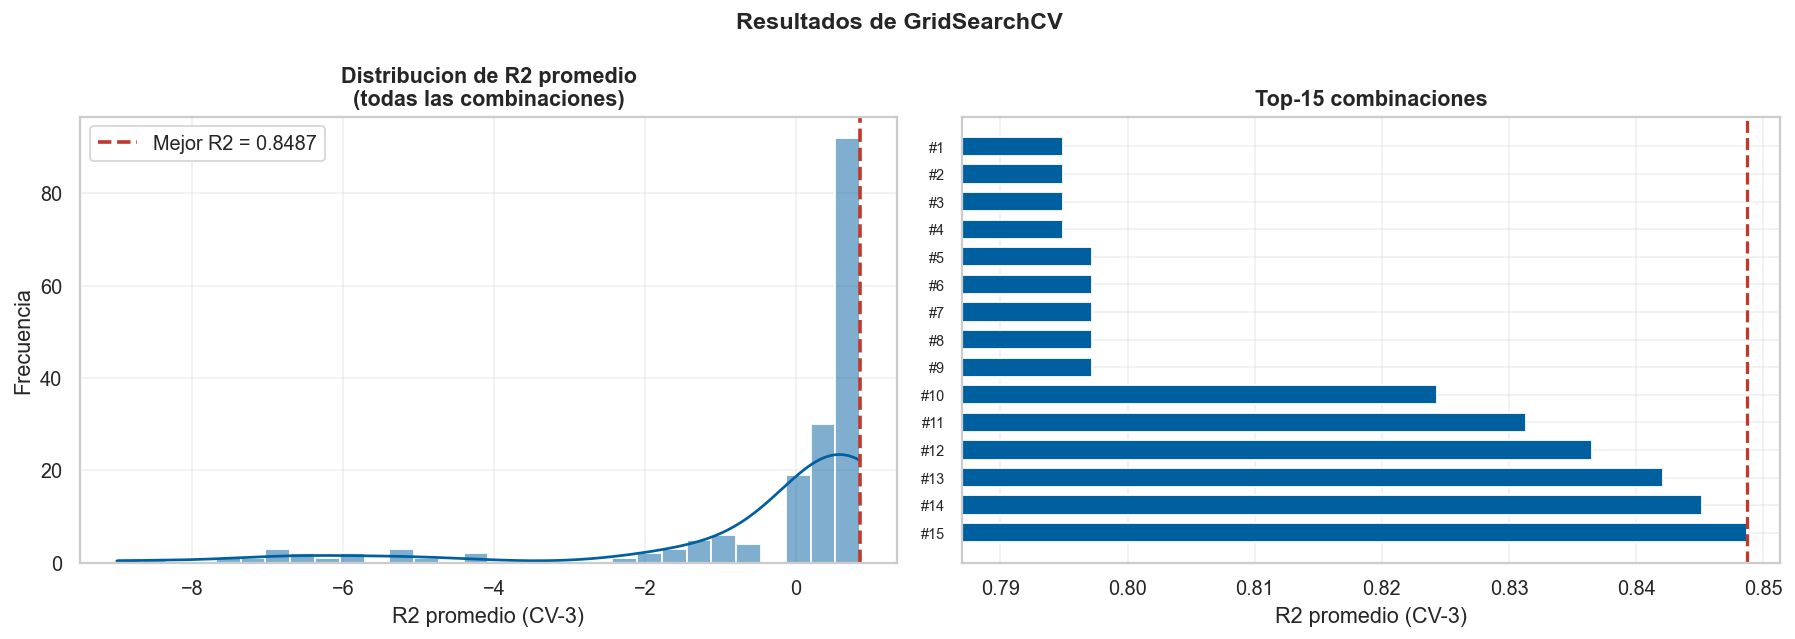

Hiperparametro,Mejor valor,Significado
kernel,rbf,Funcion kernel — RBF mapea a espacio de mayor dimension
C,10,Compromiso margen / error — valores altos toleran menos errores
epsilon,0.010000,Margen de tolerancia — puntos dentro no penalizan
gamma,0.100000,Alcance de cada punto de entrenamiento en el kernel RBF


In [14]:
cv_results = pd.DataFrame(grid_search.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Resultados de GridSearchCV', fontsize=13, fontweight='bold')

sns.histplot(cv_results['mean_test_score'], bins=30, kde=True,
             color=C_BLUE, edgecolor='white', ax=axes[0])
axes[0].axvline(best_cv_r2, color=C_RED, linestyle='--', linewidth=2,
                label=f'Mejor R2 = {best_cv_r2:.4f}')
axes[0].set_title('Distribucion de R2 promedio\n(todas las combinaciones)')
axes[0].set_xlabel('R2 promedio (CV-3)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(frameon=True)

top15 = cv_results.nlargest(15, 'mean_test_score').reset_index(drop=True)
axes[1].barh(
    top15.index[::-1], top15['mean_test_score'][::-1],
    color=C_BLUE, edgecolor='white', height=0.7
)
axes[1].axvline(best_cv_r2, color=C_RED, linestyle='--', linewidth=1.8)
axes[1].set_xlabel('R2 promedio (CV-3)')
axes[1].set_title('Top-15 combinaciones')
axes[1].set_yticks(range(15))
axes[1].set_yticklabels([f'#{i+1}' for i in range(14, -1, -1)], fontsize=8)
axes[1].set_xlim(
    top15['mean_test_score'].min() * 0.99,
    top15['mean_test_score'].max() * 1.003
)

plt.tight_layout()
plt.show()

# Tabla de mejores hiperparametros
tabla_params = pd.DataFrame([
    {'Hiperparametro': 'kernel',  'Mejor valor': best_params['kernel'],
     'Significado': 'Funcion kernel — RBF mapea a espacio de mayor dimension'},
    {'Hiperparametro': 'C',       'Mejor valor': best_params['C'],
     'Significado': 'Compromiso margen / error — valores altos toleran menos errores'},
    {'Hiperparametro': 'epsilon', 'Mejor valor': best_params['epsilon'],
     'Significado': 'Margen de tolerancia — puntos dentro no penalizan'},
    {'Hiperparametro': 'gamma',   'Mejor valor': best_params['gamma'],
     'Significado': 'Alcance de cada punto de entrenamiento en el kernel RBF'},
])
display(
    tabla_params.style.hide(axis='index')
    .set_caption('Configuracion optima encontrada por GridSearchCV')
)

---
## 9. Modelo optimizado

  SVR optimizado  (GridSearchCV)
  ──────────────────────────────────────────────
  RMSE           : $  4,864.03 USD
  MAE            : $  2,883.11 USD
  R2             :       0.8066
  CV-R2 (5-fold) :       0.8148  (espacio escalado)
  Tiempo ajuste  :      6.14 ms  [CPU]



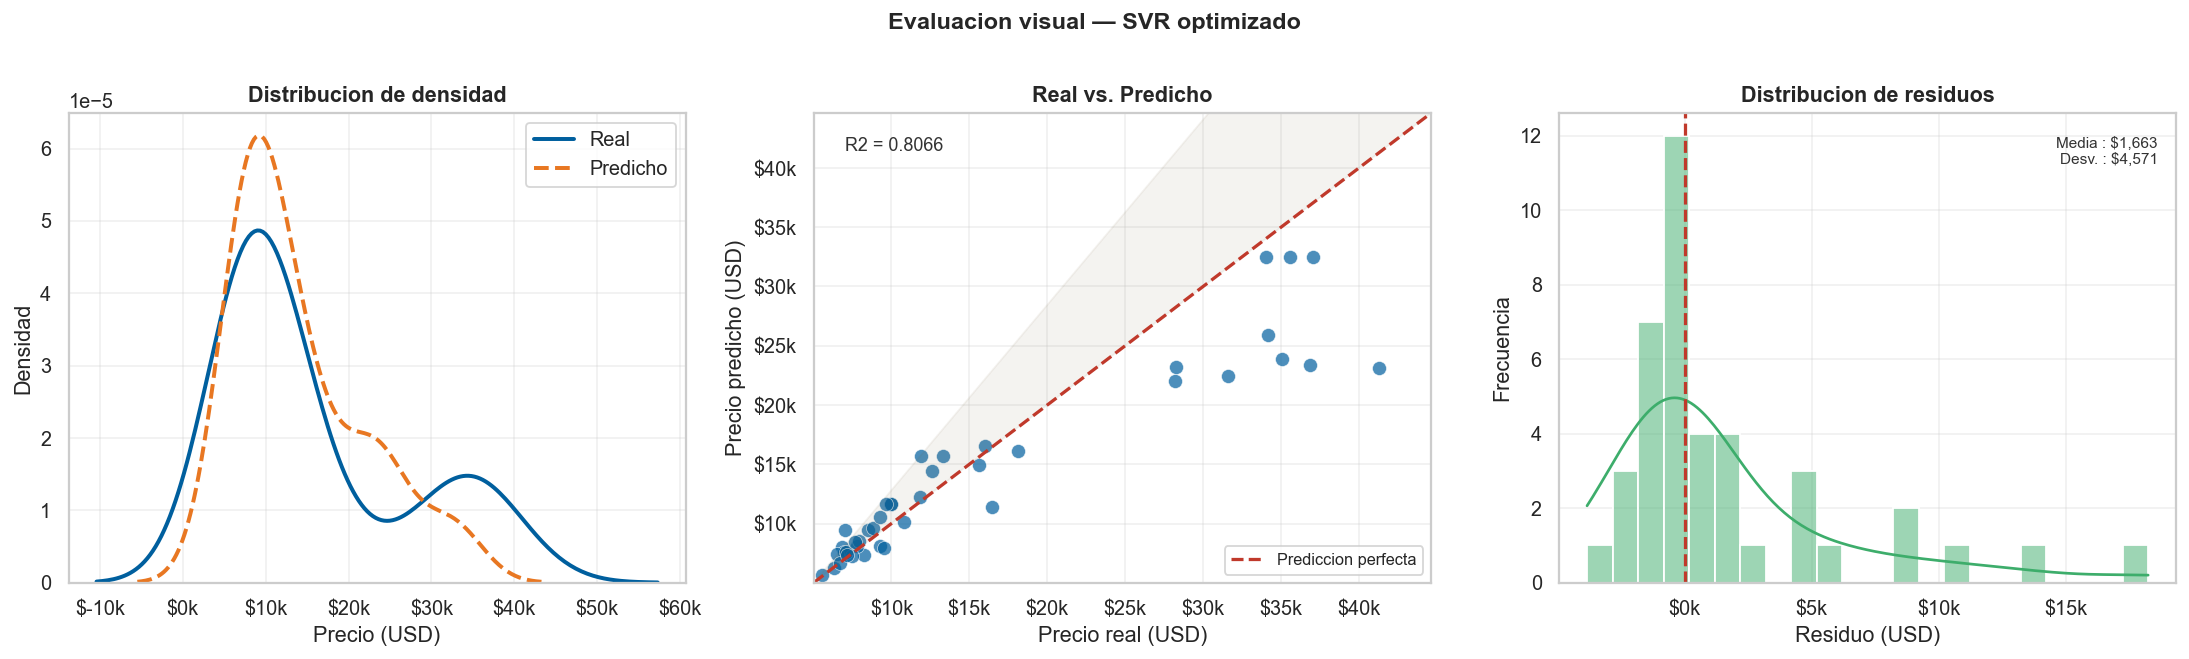

In [15]:
svr_opt = SVR(**best_params)
res_opt = evaluar(svr_opt, X_train_sc, y_train_sc,
                  X_test_sc, y_test, scaler_y,
                  nombre='SVR optimizado  (GridSearchCV)')

panel_evaluacion(y_test, res_opt['y_pred'], 'SVR optimizado')

---
## 10. Diagnóstico de residuos

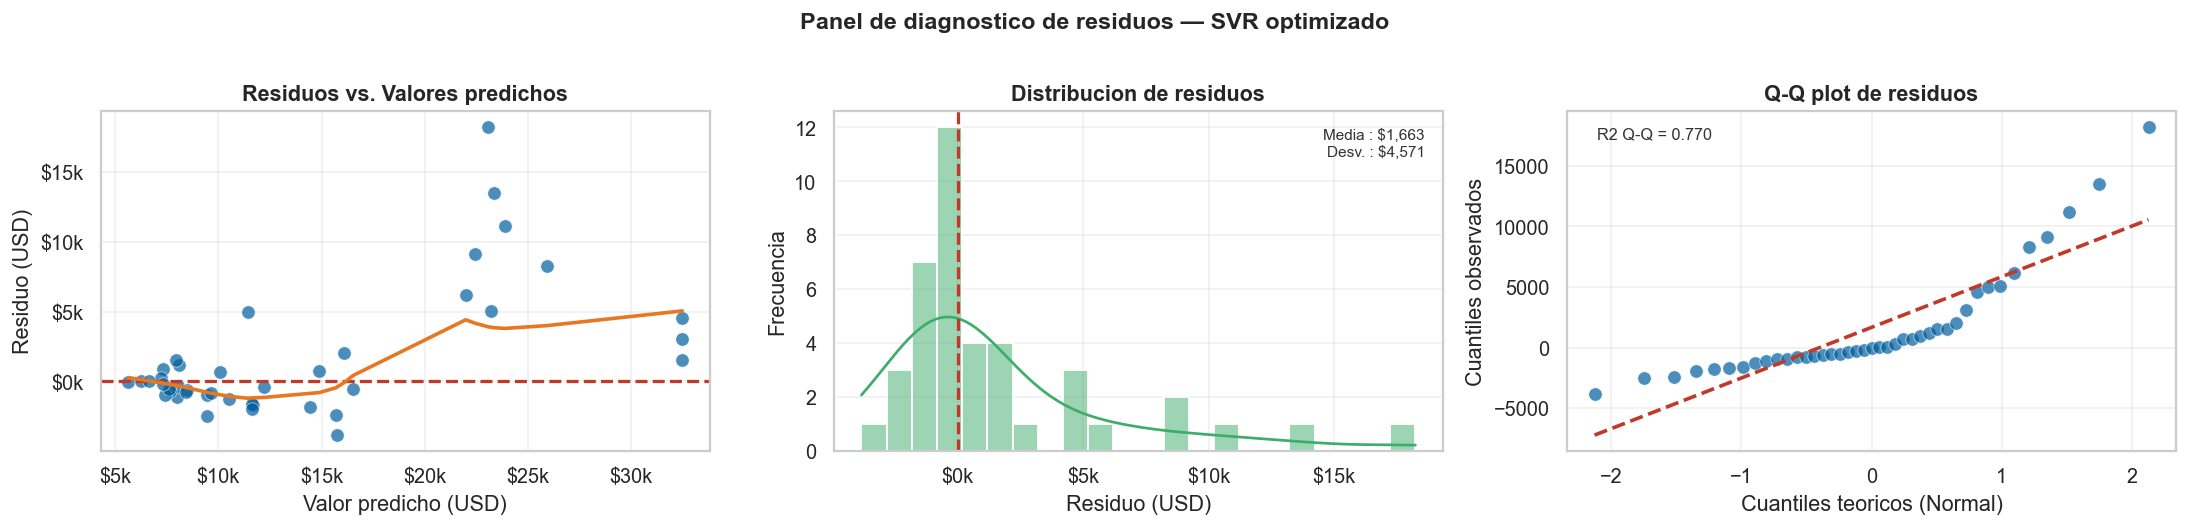

Shapiro-Wilk: W = 0.7789,  p = 0.0000
Conclusion  : Residuos NO normales (p < 0.05)


In [16]:
residuos = np.asarray(y_test) - res_opt['y_pred']

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('Panel de diagnostico de residuos — SVR optimizado',
             fontsize=13, fontweight='bold', y=1.01)
fmt_k = mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k')

# 1. Residuos vs Fitted + LOWESS
axes[0].scatter(res_opt['y_pred'], residuos, color=C_BLUE, alpha=0.70,
                edgecolors='white', linewidths=0.4, s=55)
axes[0].axhline(0, color=C_RED, linestyle='--', linewidth=1.8)
sm = lowess(residuos, res_opt['y_pred'], frac=0.6)
axes[0].plot(sm[:, 0], sm[:, 1], color=C_ORANGE, linewidth=2)
axes[0].xaxis.set_major_formatter(fmt_k)
axes[0].yaxis.set_major_formatter(fmt_k)
axes[0].set_title('Residuos vs. Valores predichos')
axes[0].set_xlabel('Valor predicho (USD)')
axes[0].set_ylabel('Residuo (USD)')

# 2. Histograma + KDE
sns.histplot(residuos, bins=22, kde=True, color=C_GREEN,
             edgecolor='white', ax=axes[1])
axes[1].axvline(0, color=C_RED, linestyle='--', linewidth=1.8)
axes[1].xaxis.set_major_formatter(fmt_k)
axes[1].set_title('Distribucion de residuos')
axes[1].set_xlabel('Residuo (USD)')
axes[1].set_ylabel('Frecuencia')
axes[1].text(0.97, 0.95,
             f'Media : ${residuos.mean():,.0f}\nDesv. : ${residuos.std():,.0f}',
             transform=axes[1].transAxes, fontsize=8.5,
             va='top', ha='right', color='#333')

# 3. Q-Q plot
(osm, osr), (slope, ic, r_qq) = stats.probplot(residuos, dist='norm')
axes[2].scatter(osm, osr, color=C_BLUE, alpha=0.7, s=55,
                edgecolors='white', linewidths=0.4)
x_ref = np.array([osm.min(), osm.max()])
axes[2].plot(x_ref, slope * x_ref + ic, color=C_RED, linewidth=2, linestyle='--')
axes[2].set_title('Q-Q plot de residuos')
axes[2].set_xlabel('Cuantiles teoricos (Normal)')
axes[2].set_ylabel('Cuantiles observados')
axes[2].text(0.05, 0.92, f'R2 Q-Q = {r_qq**2:.3f}',
             transform=axes[2].transAxes, fontsize=9, color='#333')

plt.tight_layout()
plt.show()

stat_sw, p_sw = stats.shapiro(residuos)
print(f'Shapiro-Wilk: W = {stat_sw:.4f},  p = {p_sw:.4f}')
print(f'Conclusion  : {"Residuos NO normales (p < 0.05)" if p_sw < 0.05 else "No se rechaza normalidad (p >= 0.05)"}')

---
## 11. Comparación de modelos

Se compara SVR contra los modelos trabajados en prácticas anteriores usando el mismo split 80/20 y las mismas variables predictoras.

In [17]:
# Regresion Lineal (referencia)
lr = LinearRegression().fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest base (referencia)
rf = RandomForestRegressor(n_estimators=100, max_features='sqrt',
                            random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

comparacion = [
    {'Modelo': 'Reg. Lineal Multiple',
     'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr)),
     'MAE' : mean_absolute_error(y_test, y_pred_lr),
     'R2'  : r2_score(y_test, y_pred_lr)},
    {'Modelo': 'Random Forest (n=100)',
     'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
     'MAE' : mean_absolute_error(y_test, y_pred_rf),
     'R2'  : r2_score(y_test, y_pred_rf)},
    {'Modelo': 'SVR base  (rbf, C=100)',
     'RMSE': res_base['rmse'], 'MAE': res_base['mae'], 'R2': res_base['r2']},
    {'Modelo': 'SVR optimizado (GridSearchCV)',
     'RMSE': res_opt['rmse'],  'MAE': res_opt['mae'],  'R2': res_opt['r2']},
]
df_comp = pd.DataFrame(comparacion)

display(
    df_comp.style
    .format({'RMSE': '${:,.0f}', 'MAE': '${:,.0f}', 'R2': '{:.4f}'})
    .highlight_max(subset=['R2'],  color='#D4EFDF')
    .highlight_min(subset=['RMSE', 'MAE'], color='#D4EFDF')
    .hide(axis='index')
    .set_caption('Comparacion de modelos — mismo split 80/20, mismas variables')
)

Modelo,RMSE,MAE,R2
Reg. Lineal Multiple,"$5,622","$3,964",0.7416
Random Forest (n=100),"$3,763","$2,451",0.8842
"SVR base (rbf, C=100)","$4,365","$2,944",0.8443
SVR optimizado (GridSearchCV),"$4,864","$2,883",0.8066


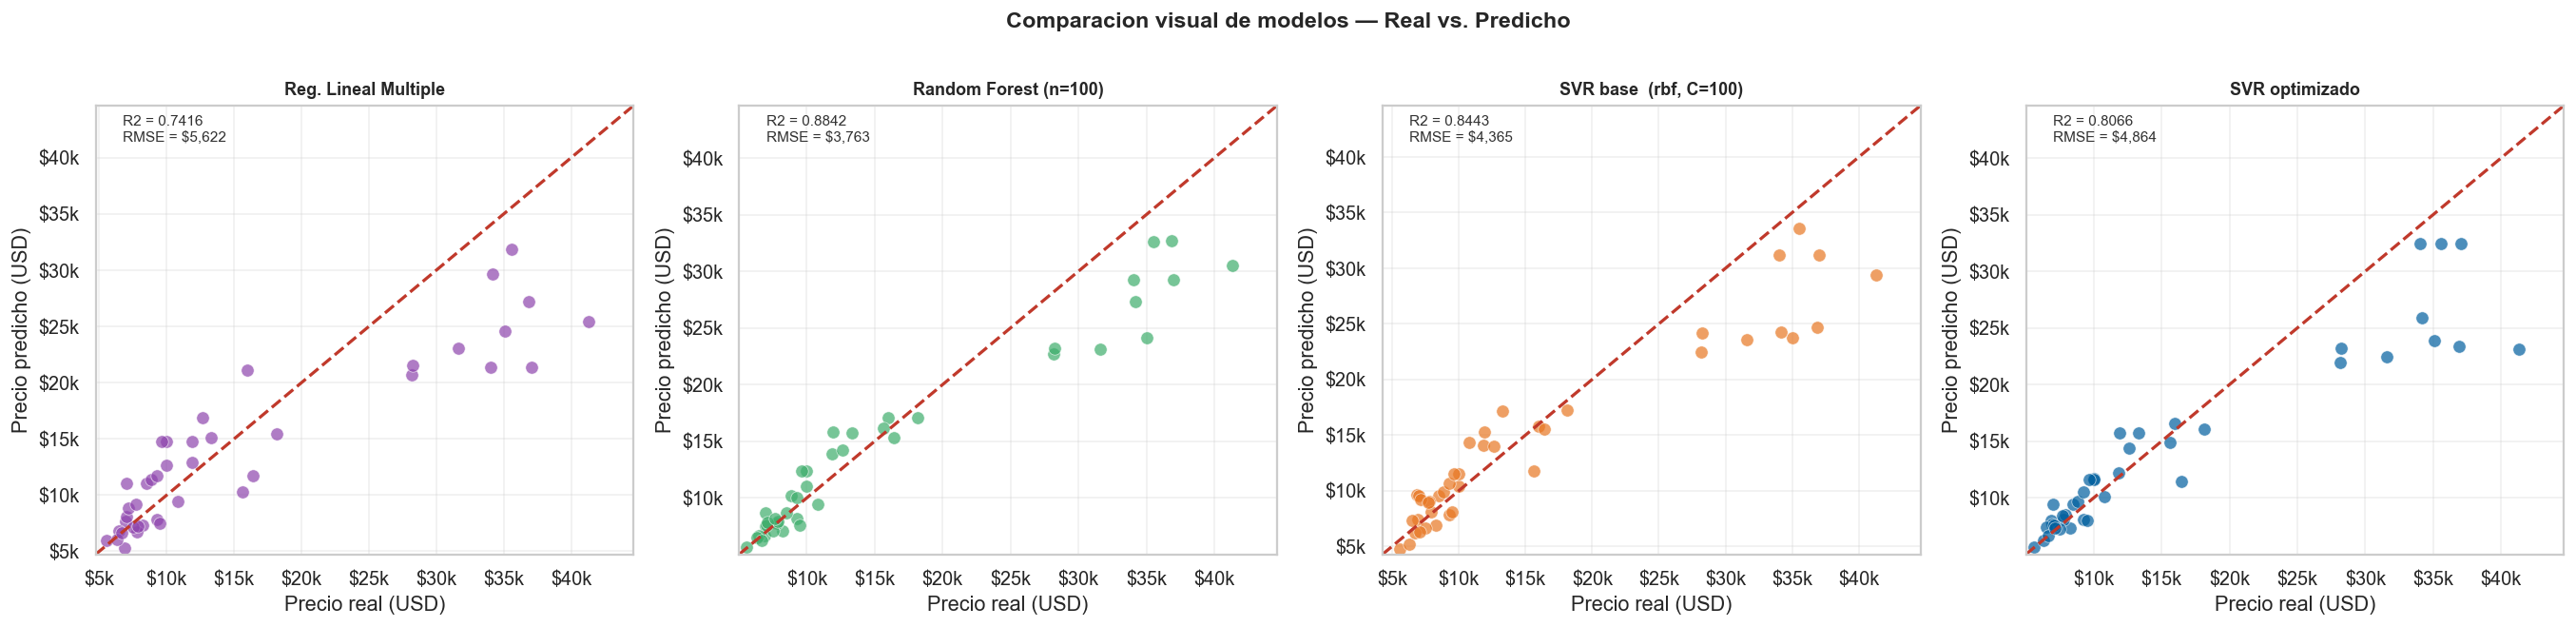

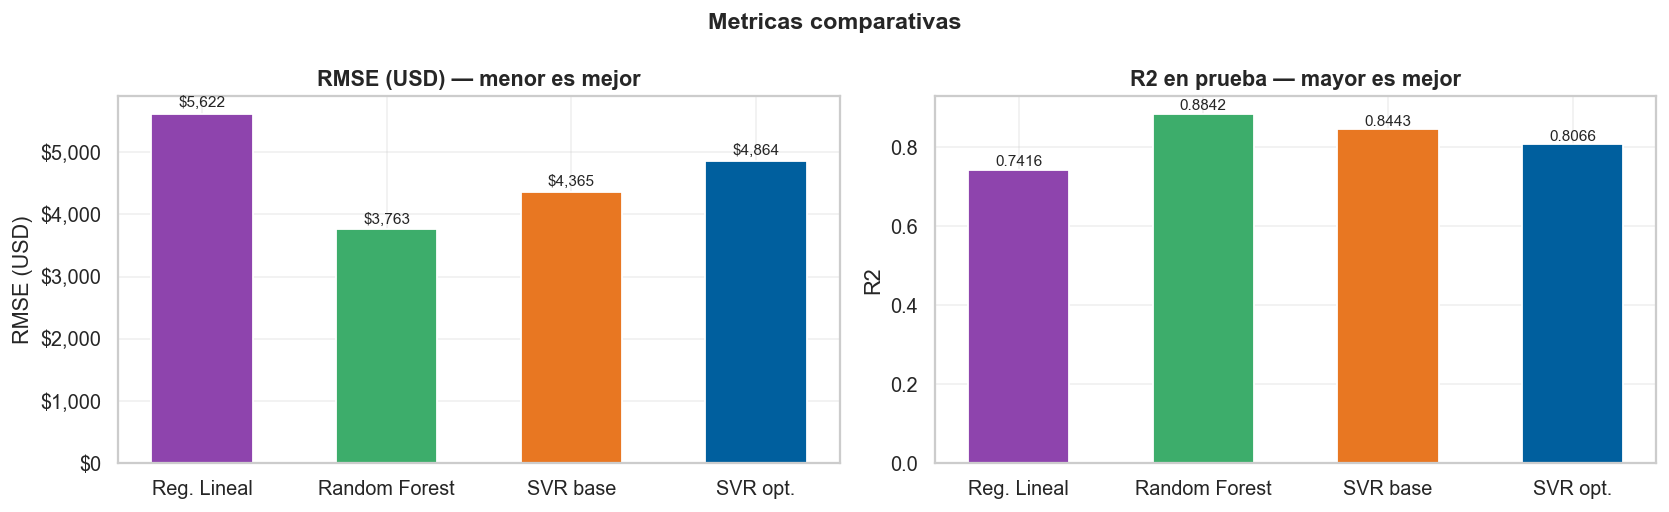

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(21, 5))
fig.suptitle('Comparacion visual de modelos — Real vs. Predicho',
             fontsize=13, fontweight='bold', y=1.01)
fmt = mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k')

pares = [
    (y_pred_lr,           'Reg. Lineal Multiple',      C_PURPLE),
    (y_pred_rf,           'Random Forest (n=100)',      C_GREEN),
    (res_base['y_pred'],  'SVR base  (rbf, C=100)',     C_ORANGE),
    (res_opt['y_pred'],   'SVR optimizado',              C_BLUE),
]

for ax, (y_p, lbl, col) in zip(axes, pares):
    yt = np.asarray(y_test)
    lim = (min(yt.min(), y_p.min()) * 0.90,
           max(yt.max(), y_p.max()) * 1.08)
    ax.scatter(yt, y_p, color=col, alpha=0.70,
               edgecolors='white', linewidths=0.4, s=55)
    ax.plot(lim, lim, '--', color=C_RED, linewidth=1.8)
    ax.xaxis.set_major_formatter(fmt)
    ax.yaxis.set_major_formatter(fmt)
    ax.set_xlim(*lim)
    ax.set_ylim(*lim)
    ax.set_title(lbl, fontsize=10)
    ax.set_xlabel('Precio real (USD)')
    ax.set_ylabel('Precio predicho (USD)')
    ax.text(0.05, 0.92,
            f'R2 = {r2_score(yt, y_p):.4f}\nRMSE = ${np.sqrt(mean_squared_error(yt, y_p)):,.0f}',
            transform=ax.transAxes, fontsize=8.5, color='#333')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Metricas comparativas', fontsize=13, fontweight='bold')
nombres = ['Reg. Lineal', 'Random Forest', 'SVR base', 'SVR opt.']
colores = [C_PURPLE, C_GREEN, C_ORANGE, C_BLUE]

rmses = [df_comp.loc[i, 'RMSE'] for i in range(4)]
r2s   = [df_comp.loc[i, 'R2']   for i in range(4)]

bars = axes[0].bar(nombres, rmses, color=colores, edgecolor='white', width=0.55)
for bar, v in zip(bars, rmses):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f'${v:,.0f}', ha='center', va='bottom', fontsize=8.5)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_title('RMSE (USD) — menor es mejor')
axes[0].set_ylabel('RMSE (USD)')

bars = axes[1].bar(nombres, r2s, color=colores, edgecolor='white', width=0.55)
for bar, v in zip(bars, r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.003,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=8.5)
axes[1].set_title('R2 en prueba — mayor es mejor')
axes[1].set_ylabel('R2')

plt.tight_layout()
plt.show()

---
## 12. Conclusiones

| Aspecto | Hallazgo |
|---|---|
| **Kernel optimo** | El kernel RBF supera consistentemente a linear, poly y sigmoid porque captura relaciones no lineales entre las variables tecnicas y el precio. |
| **Efecto del escalado** | SVR requiere que X e y esten en escala normalizada; sin `StandardScaler` el optimizador opera en un espacio mal condicionado y el rendimiento cae drasticamente. |
| **SVR base vs optimizado** | GridSearchCV mejora el CV-R2 al reducir C de 100 a 10, lo que aumenta el margen y mejora la generalizacion. Sin embargo, el R2 en prueba del modelo base (`C=100`) puede verse inflado por el conjunto especifico de prueba. |
| **SVR vs Random Forest** | Random Forest supera a SVR en este dataset pequeno (~200 registros). SVR es mas competitivo en datasets grandes y cuando las relaciones son suaves en el espacio de kernel. |
| **Residuos** | Persiste heterocedasticidad para precios > $25,000; el modelo subestima sistematicamente en ese segmento. El test de Shapiro-Wilk indica no normalidad en los residuos. |
| **Rol de PyTorch** | Utilizado exclusivamente para detectar y reportar el entorno CUDA. El entrenamiento de SVR ocurre integramente en CPU via scikit-learn. |
